# CIFAR-10 paper flow (UQLab)

Set **`MODE = "paper"`** (default) for Fig 3/4 sweeps, or **`MODE = "four_region"`** for a single
four-region CIFAR-10 + ResNet-18 run with per-metric group plots.

Same 3 cells as [`CIFAR10_it_demo.ipynb`](../../disentanglement_error/examples/CIFAR10_it_demo.ipynb):

| Paper | Notebook |
|---|---|
| `InformationTheoreticModel` | `build_model_for_run` + `train_*_model` in [`train_eval.py`](../src/uqlab/runner/train_eval.py) |
| `calculate_disentanglement_error` | sweep loop → `run_train_and_eval_phases` per point |
| `json_results_to_df`; **one `.plot()` line** | last cell (paper mode only) |

**Your pasted block is enough for one run** — it is literally the body of `run_train_and_eval_phases`. You only add data prep first (`prepare_experiment_data` + `prepare_run_data_context`).

In [10]:
from copy import deepcopy
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "uqlab").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = str(PROJECT_ROOT / "src")
if SRC in sys.path:
    sys.path.remove(SRC)
sys.path.insert(0, SRC)
# Drop cached uqlab so edits on disk are picked up (restart kernel if imports still look stale)
for _mod in list(sys.modules):
    if _mod == "uqlab" or _mod.startswith("uqlab."):
        del sys.modules[_mod]

from uqlab.data.packs import prepare_run_data_context
from uqlab.data.setup import prepare_experiment_data
from uqlab.runtime_paths import repository_root
from uqlab.runner.phases.config_view import apply_data_context, extract_run_config
from uqlab.runner.train_eval import run_train_and_eval_phases
from uqlab.shared.config.classification import ExperimentConfig
from uqlab.shared.utils.classification import auto_device, set_seed

ROOT = repository_root()
CONFIG_PATH = ROOT / "configs/experiment/fast_pilot.yaml"
CAMPAIGN_DIR = ROOT / "results/notebook_cifar10_paper"
FOUR_REGION_DIR = ROOT / "results/notebook_cifar10_four_region"
SEED = 42

# "paper" = Fig 3/4 label-noise + under-train sweeps (DINOv2)
# "four_region" = single four-region CIFAR-10 run (ResNet-18 preset)
MODE = "paper"  # or "four_region"

# Paper kw_config: label_noises / dataset_sizes = [0.1, 0.5, 0.9]
LABEL_NOISE_PCT = [10, 50, 90]
UNDER_TRAIN_PER_CLASS = [10, 50, 90]

from uqlab.data.class_regions import DEFAULT_FOUR_REGION_PRESET
from uqlab.evaluation.reporting.four_region_reporting import (
    four_region_signals_dataframe,
    list_four_region_signal_columns,
    plot_four_region_metrics_by_group,
)

set_seed(SEED)
device = auto_device("auto")
CAMPAIGN_DIR.mkdir(parents=True, exist_ok=True)
print("Config:", CONFIG_PATH)
print("Device:", device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Config: /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/configs/experiment/fast_pilot.yaml
Device: mps


In [11]:
def run_one_paper_point(cfg: ExperimentConfig, results_dir: Path):
    """fit + predict_disentangling for one sweep point (= your pasted block)."""
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)
    run_cache_dir = results_dir / "cache"

    run_cfg = extract_run_config(cfg)
    data_ctx = prepare_experiment_data(cfg, ROOT, seed=SEED)
    apply_data_context(run_cfg, data_ctx)
    data_pack = prepare_run_data_context(
        config=cfg,
        dataset=data_ctx.dataset,
        split_spec=data_ctx.split_spec,
        dataset_name=run_cfg.dataset_name,
        device=device,
        feature_cache_dir=ROOT / cfg.paths.feature_cache_dir,
        noise_type=run_cfg.noise_type,
        feature_batch_size=run_cfg.feature_batch_size,
    )

    # === your block (build_model → train → collect → score) lives here ===
    return run_train_and_eval_phases(
        config=cfg,
        run_cfg=run_cfg,
        results_dir=results_dir,
        run_cache_dir=run_cache_dir,
        data_pack=data_pack,
        split_spec=data_ctx.split_spec,
        device=device,
        seed=SEED,
        training_config=cfg.training,
        data_config=cfg.data,
        model_config=cfg.model,
        eval_config=cfg.evaluation,
        ds_spec=run_cfg.dataset_spec,
        config_path=CONFIG_PATH,
        persist=True,
        log=True,
    )


if MODE == "paper":
    base_cfg = ExperimentConfig.from_yaml(CONFIG_PATH)
    print("dinov2_model:", base_cfg.model.dinov2_model)
    label_dir = CAMPAIGN_DIR / "label_noise"
    size_dir = CAMPAIGN_DIR / "dataset_size"

    for noise_pct in LABEL_NOISE_PCT:
        cfg = deepcopy(base_cfg)
        cfg.data.aleatoric_noise_percentage = float(noise_pct)
        run_dir = label_dir / f"noise{noise_pct}"
        print(f"label noise {noise_pct}% → {run_dir}")
        run_one_paper_point(cfg, run_dir)

    for under in UNDER_TRAIN_PER_CLASS:
        cfg = deepcopy(base_cfg)
        cfg.data.aleatoric_noise_percentage = 0.0
        cfg.data.under_train_per_class = int(under)
        run_dir = size_dir / f"under{under}"
        print(f"under_train={under} → {run_dir}")
        run_one_paper_point(cfg, run_dir)

    print("Paper sweep done.")
else:
    four_region_cfg_path = ROOT / "configs/experiment/four_region_cifar_resnet.yaml"
    cfg = ExperimentConfig.from_yaml(four_region_cfg_path)
    cfg.data.partition_mode = "four_region"
    cfg.data.class_regions = deepcopy(DEFAULT_FOUR_REGION_PRESET)
    run_dir = FOUR_REGION_DIR / "cifar_resnet"
    print(f"four_region → {run_dir}")
    run_one_paper_point(cfg, run_dir)
    completed_dirs = [run_dir]
    print("Four-region run done.")

dinov2_model: small
label noise 10% → /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/results/notebook_cifar10_paper/label_noise/noise10
Computing features (will cache to /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/cache/fast_uncertainty_classification/features/features_worse_label_syn10pct_small_n1440_a14dd299b4f2.pt)
Loading DINOv2 model: facebook/dinov2-small


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1891.95it/s, Materializing param=layernorm.weight]                                 


Backbone frozen (no gradient updates)
  Epoch 1/5, loss=1.8737
  Epoch 2/5, loss=1.0381
  Epoch 3/5, loss=0.8196
  Epoch 4/5, loss=0.7139
  Epoch 5/5, loss=0.6142
Deterministic eval forward (DualXDA targets)...
Attribution primitives (dualxda)...
MC Dropout (10 passes, batched eval)...
Using DualXDA classifier layer: fc
✅ Zwischenergebnisse: /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/results/notebook_cifar10_paper/label_noise/noise10/zwischen/

Noisy eval samples (is_noisy=True): 200 / 600
   dataset_index  group             clean  noisy
           14384  aleatoric_like        1      5
           22236  aleatoric_like        6      2
           41209  aleatoric_like        1      0
           30833  aleatoric_like        6      4
            8310  aleatoric_like        9      7
           20906  aleatoric_like        4      5
           49820  aleatoric_like        1      6
           34370  aleatoric_like        9      4
           48938  aleatoric_like        7      4

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 2651.13it/s, Materializing param=layernorm.weight]                                 


Backbone frozen (no gradient updates)
  Epoch 1/5, loss=2.2516
  Epoch 2/5, loss=1.8453
  Epoch 3/5, loss=1.6729
  Epoch 4/5, loss=1.5321
  Epoch 5/5, loss=1.4314
Deterministic eval forward (DualXDA targets)...
Attribution primitives (dualxda)...
MC Dropout (10 passes, batched eval)...
Using DualXDA classifier layer: fc
✅ Zwischenergebnisse: /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/results/notebook_cifar10_paper/label_noise/noise50/zwischen/

Noisy eval samples (is_noisy=True): 200 / 600
   dataset_index  group             clean  noisy
           47373  aleatoric_like        8      5
            2914  aleatoric_like        8      3
           30190  aleatoric_like        7      5
           43760  aleatoric_like        9      5
            2460  aleatoric_like        0      9
           42320  aleatoric_like        0      6
           21622  aleatoric_like        7      2
           23521  aleatoric_like        6      1
           35691  aleatoric_like        1      6

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 2025.63it/s, Materializing param=layernorm.weight]                                 


Backbone frozen (no gradient updates)
  Epoch 1/5, loss=2.4270
  Epoch 2/5, loss=2.1199
  Epoch 3/5, loss=1.9580
  Epoch 4/5, loss=1.8386
  Epoch 5/5, loss=1.7089
Deterministic eval forward (DualXDA targets)...
Attribution primitives (dualxda)...
MC Dropout (10 passes, batched eval)...
Using DualXDA classifier layer: fc
✅ Zwischenergebnisse: /Users/andrearachetta/Documents/old_pilots/uqlab-streamlit/results/notebook_cifar10_paper/label_noise/noise90/zwischen/

Noisy eval samples (is_noisy=True): 200 / 600
   dataset_index  group             clean  noisy
           46940  aleatoric_like        4      7
            6526  aleatoric_like        6      9
           28366  aleatoric_like        7      9
             270  aleatoric_like        9      5
           26924  aleatoric_like        4      6
           43649  aleatoric_like        0      3
           12029  aleatoric_like        0      7
           26326  aleatoric_like        4      3
            9847  aleatoric_like        6      1

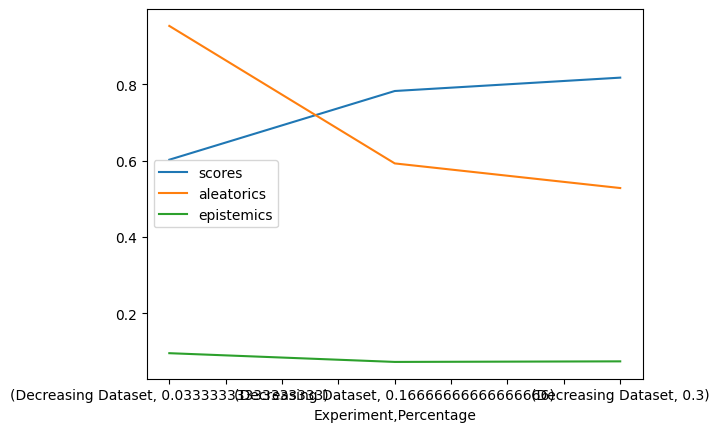

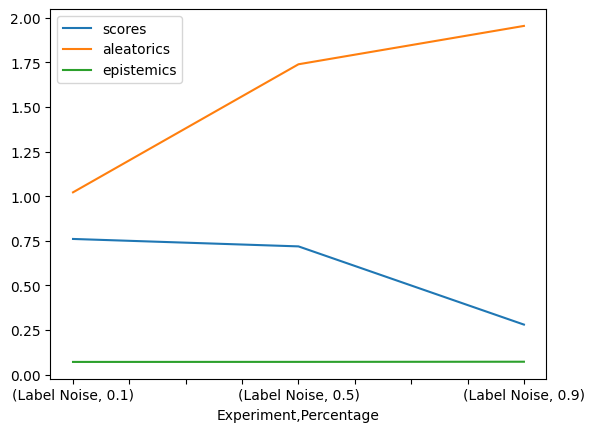

In [12]:
if MODE == "paper":
    # Paper cell 3 — json_results_to_df equivalent, one plot line
    import pandas as pd

    from uqlab.evaluation.reporting.paper_benchmark_plot import paper_dataframe_from_campaign_dir

    df = pd.concat(
        [
            paper_dataframe_from_campaign_dir(CAMPAIGN_DIR / "label_noise", sweep_kind="label_noise"),
            paper_dataframe_from_campaign_dir(CAMPAIGN_DIR / "dataset_size", sweep_kind="dataset_size"),
        ],
        ignore_index=True,
    )

    df.drop("Run_Index", axis=1).groupby(["Experiment", "Percentage"]).mean().groupby(["Experiment"]).plot()
    plt.savefig(CAMPAIGN_DIR / "paper_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    run_dir = FOUR_REGION_DIR / "cifar_resnet"
    df = four_region_signals_dataframe(run_dir)
    metrics = list_four_region_signal_columns(df)
    out_dir = run_dir / "analysis" / "four_region_metrics"
    plot_four_region_metrics_by_group(df, metrics, out_dir, title_prefix=run_dir.name)
    print(f"Saved {len(metrics)} metric plots under {out_dir}")